In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/credit_risk_dataset_cleaned.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32569,57,53000,MORTGAGE,1,PERSONAL,C,5800,13.16,0,0.11,N,30
32570,54,120000,MORTGAGE,4,PERSONAL,A,17625,7.49,0,0.15,N,19
32571,65,76000,RENT,3,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32572,56,150000,MORTGAGE,5,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length               int64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32574 non-null  int64  
 1   person_income               32574 non-null  int64  
 2   person_home_ownership       32574 non-null  object 
 3   person_emp_length           32574 non-null  int64  
 4   loan_intent                 32574 non-null  object 
 5   loan_grade                  32574 non-null  object 
 6   loan_amnt                   32574 non-null  int64  
 7   loan_int_rate               32574 non-null  float64
 8   loan_status                 32574 non-null  int64  
 9   loan_percent_income         32574 non-null  float64
 10  cb_person_default_on_file   32574 non-null  object 
 11  cb_person_cred_hist_length  32574 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
person_age,32574.0,27.718426,6.204987,20.00,23.00,26.00,30.00,94.00
person_income,32574.0,65878.480813,52531.938809,4000.00,38500.00,55000.00,79200.00,2039784.00
person_emp_length,32574.0,4.760576,3.981181,0.00,2.00,4.00,7.00,41.00
loan_amnt,32574.0,9588.018051,6320.249598,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,32574.0,11.009470,3.081664,5.42,8.49,10.99,13.11,23.22
loan_status,32574.0,0.218180,0.413017,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32574.0,0.170202,0.106755,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32574.0,5.804108,4.053873,2.00,3.00,4.00,8.00,30.00


In [6]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

person_age
Skew : 1.94


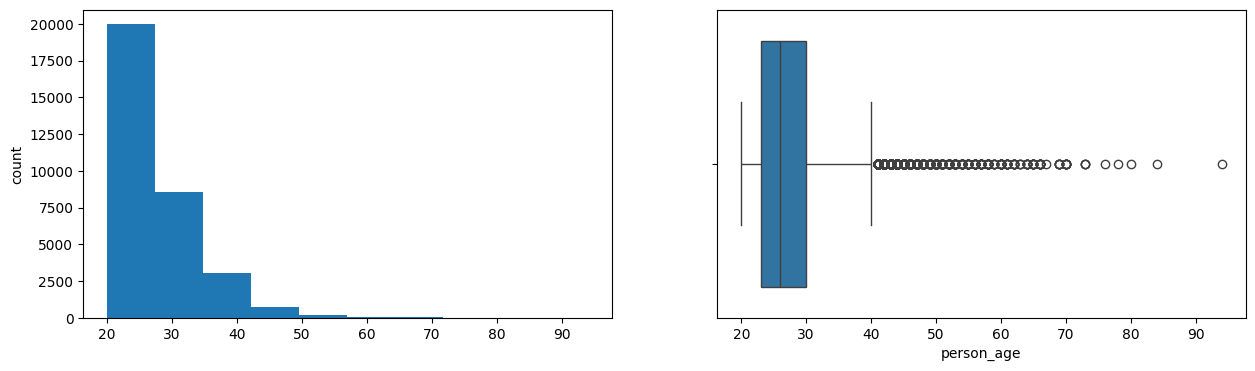

person_income
Skew : 9.76


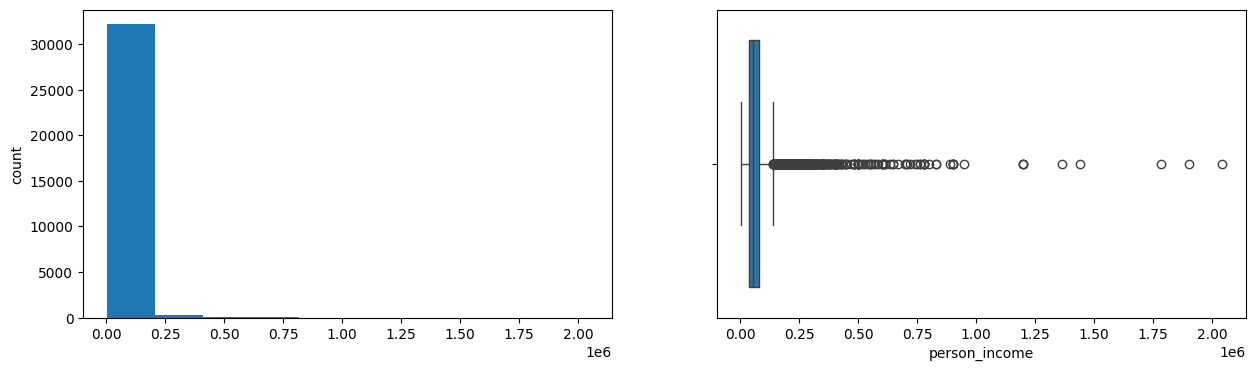

person_emp_length
Skew : 1.28


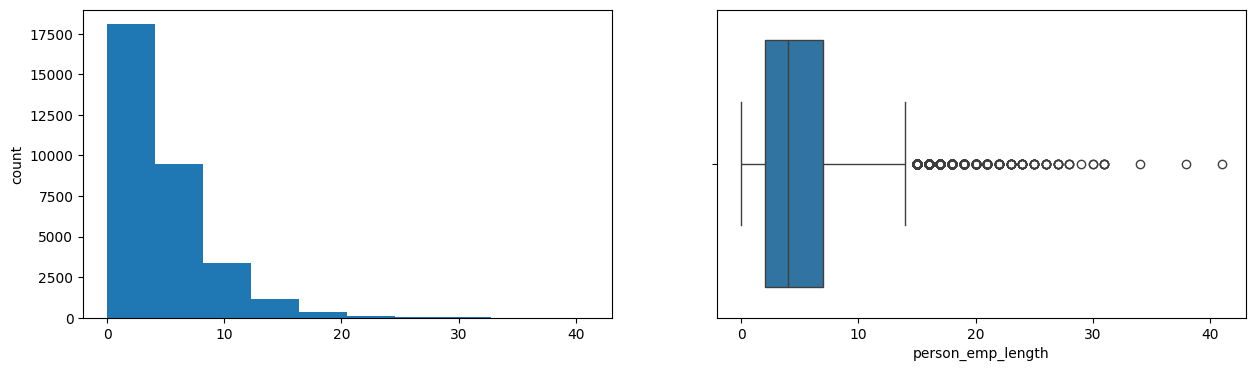

loan_amnt
Skew : 1.19


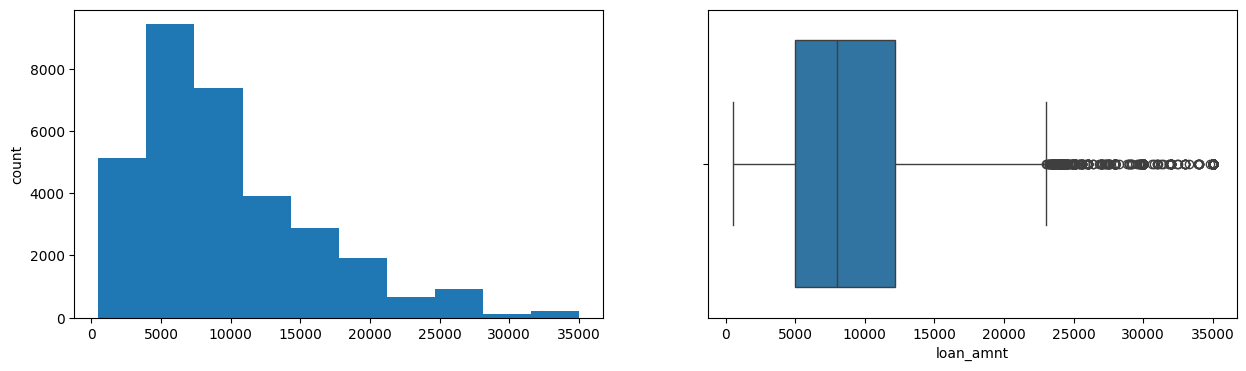

loan_int_rate
Skew : 0.22


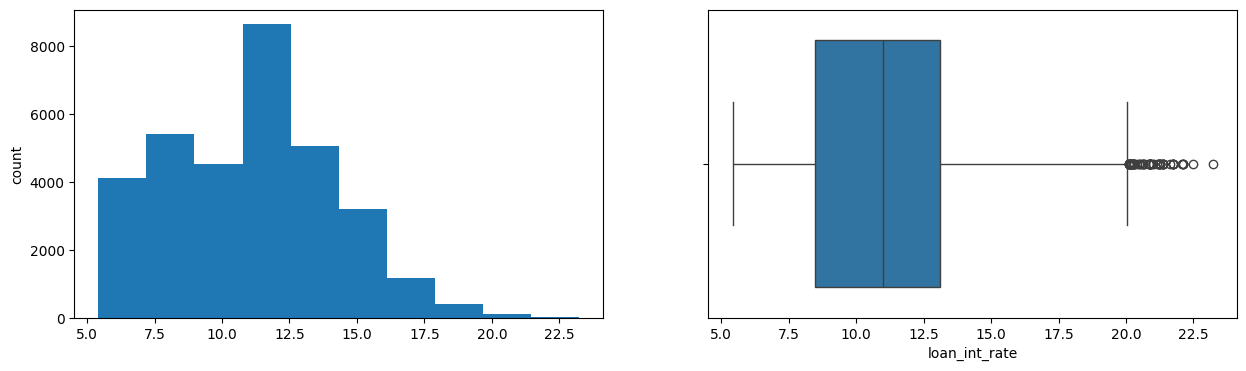

loan_status
Skew : 1.36


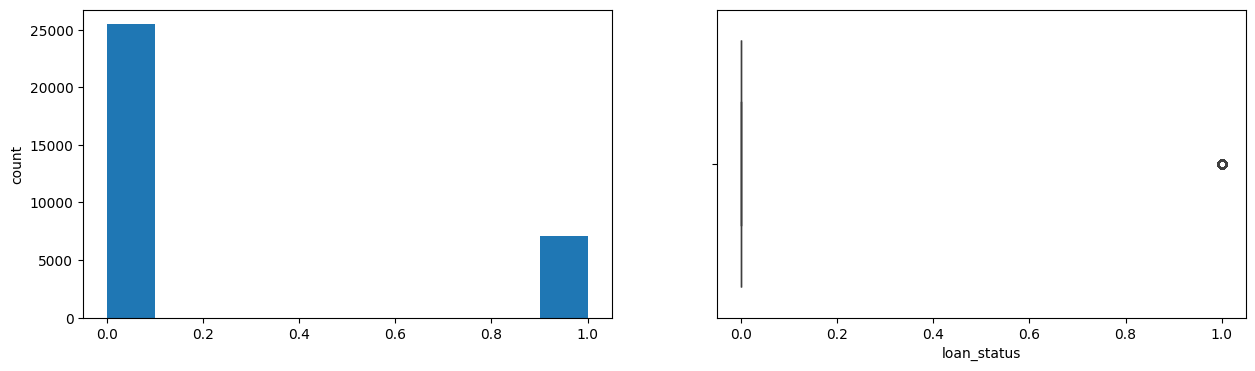

loan_percent_income
Skew : 1.06


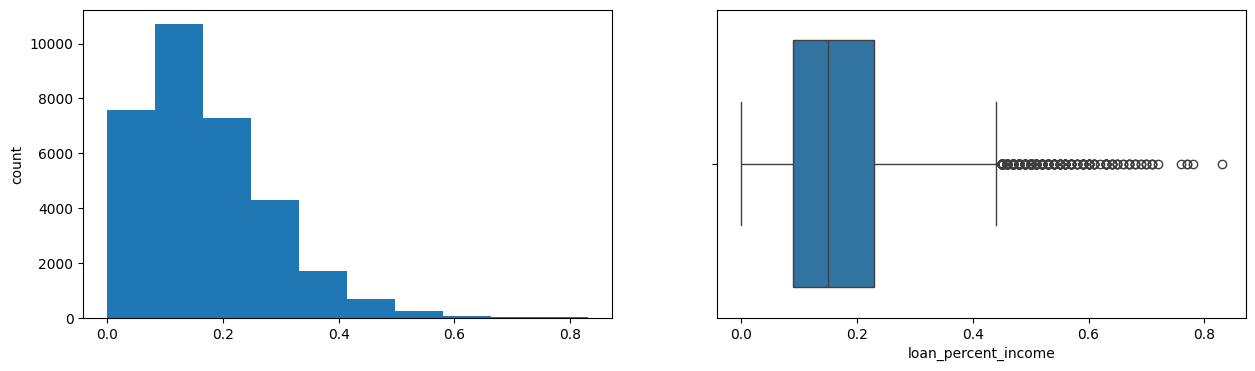

cb_person_cred_hist_length
Skew : 1.66


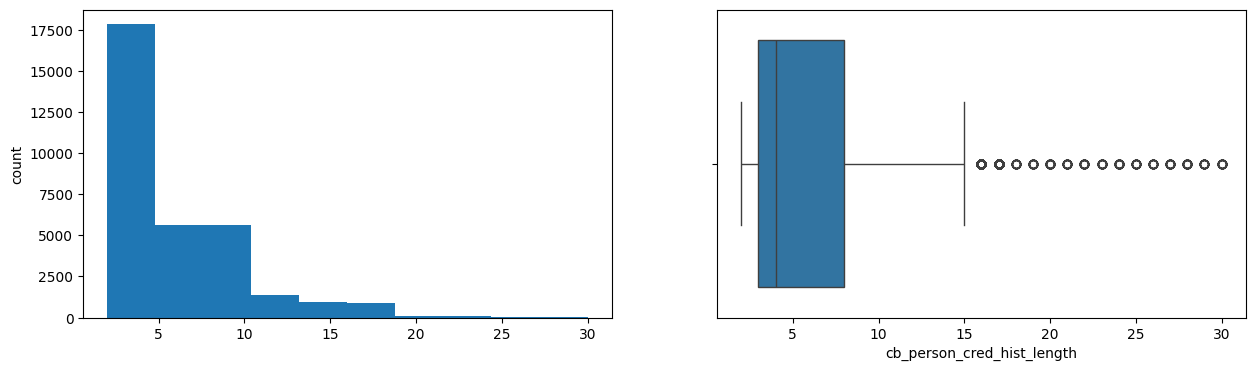

In [7]:
for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.show()

In [8]:
cat_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

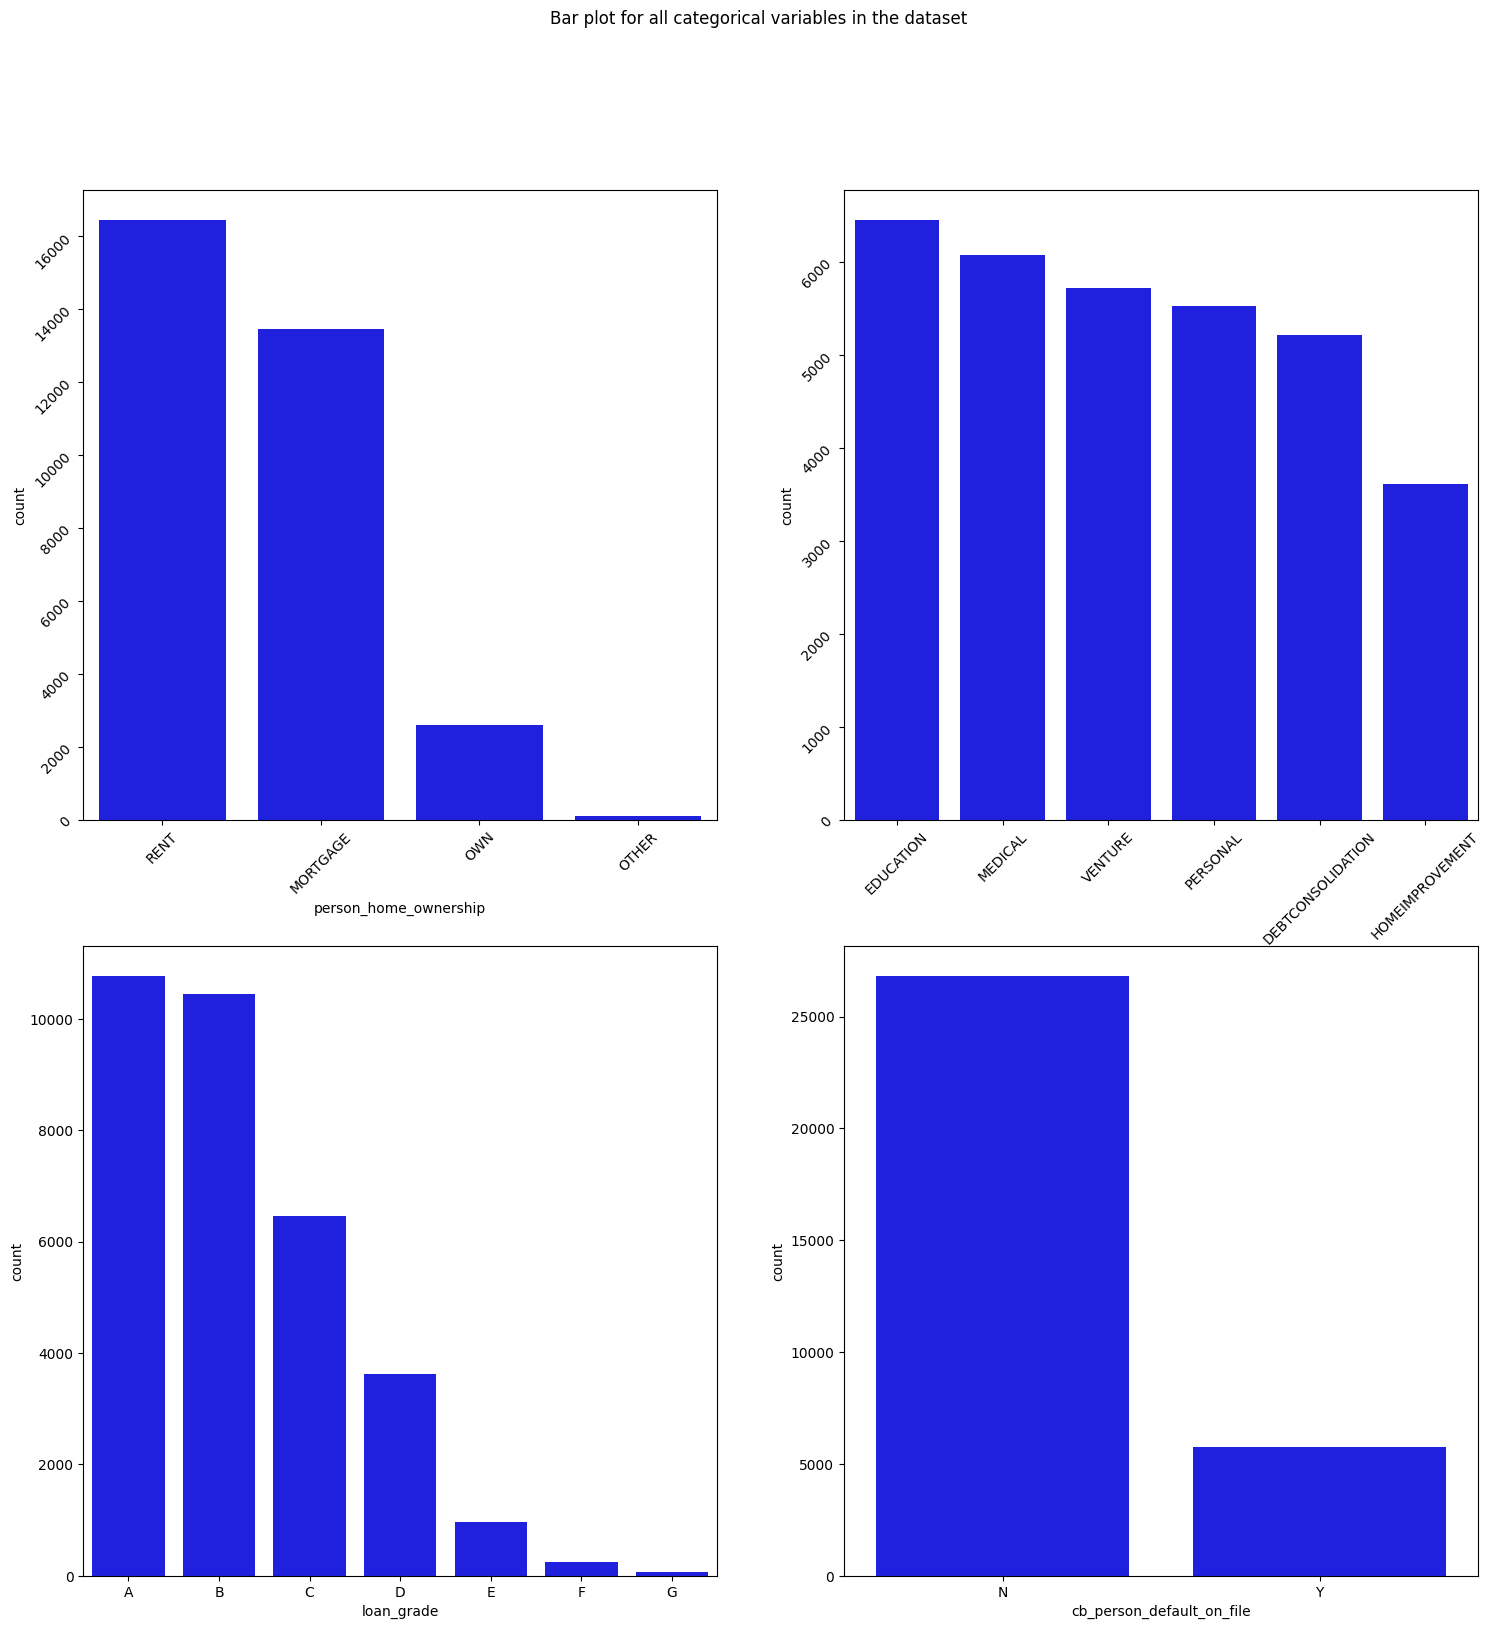

In [9]:
fig, axes = plt.subplots(2, 2, figsize = (18, 18))
fig.suptitle('Bar plot for all categorical variables in the dataset')

sns.countplot(ax = axes[0, 0], x = 'person_home_ownership', data = df, color = 'blue', 
              order = df['person_home_ownership'].value_counts().index);
sns.countplot(ax = axes[0, 1], x = 'loan_intent', data = df, color = 'blue', 
              order = df['loan_intent'].value_counts().index);
sns.countplot(ax = axes[1, 0], x = 'loan_grade', data = df, color = 'blue', 
              order = df['loan_grade'].value_counts().index);
sns.countplot(ax = axes[1, 1], x = 'cb_person_default_on_file', data = df, color = 'blue', 
              order = df['cb_person_default_on_file'].value_counts().index);

axes[0][0].tick_params(labelrotation=45);
axes[0][1].tick_params(labelrotation=45);
# axes[2][1].tick_params(labelrotation=90);

<Figure size 1800x1800 with 0 Axes>

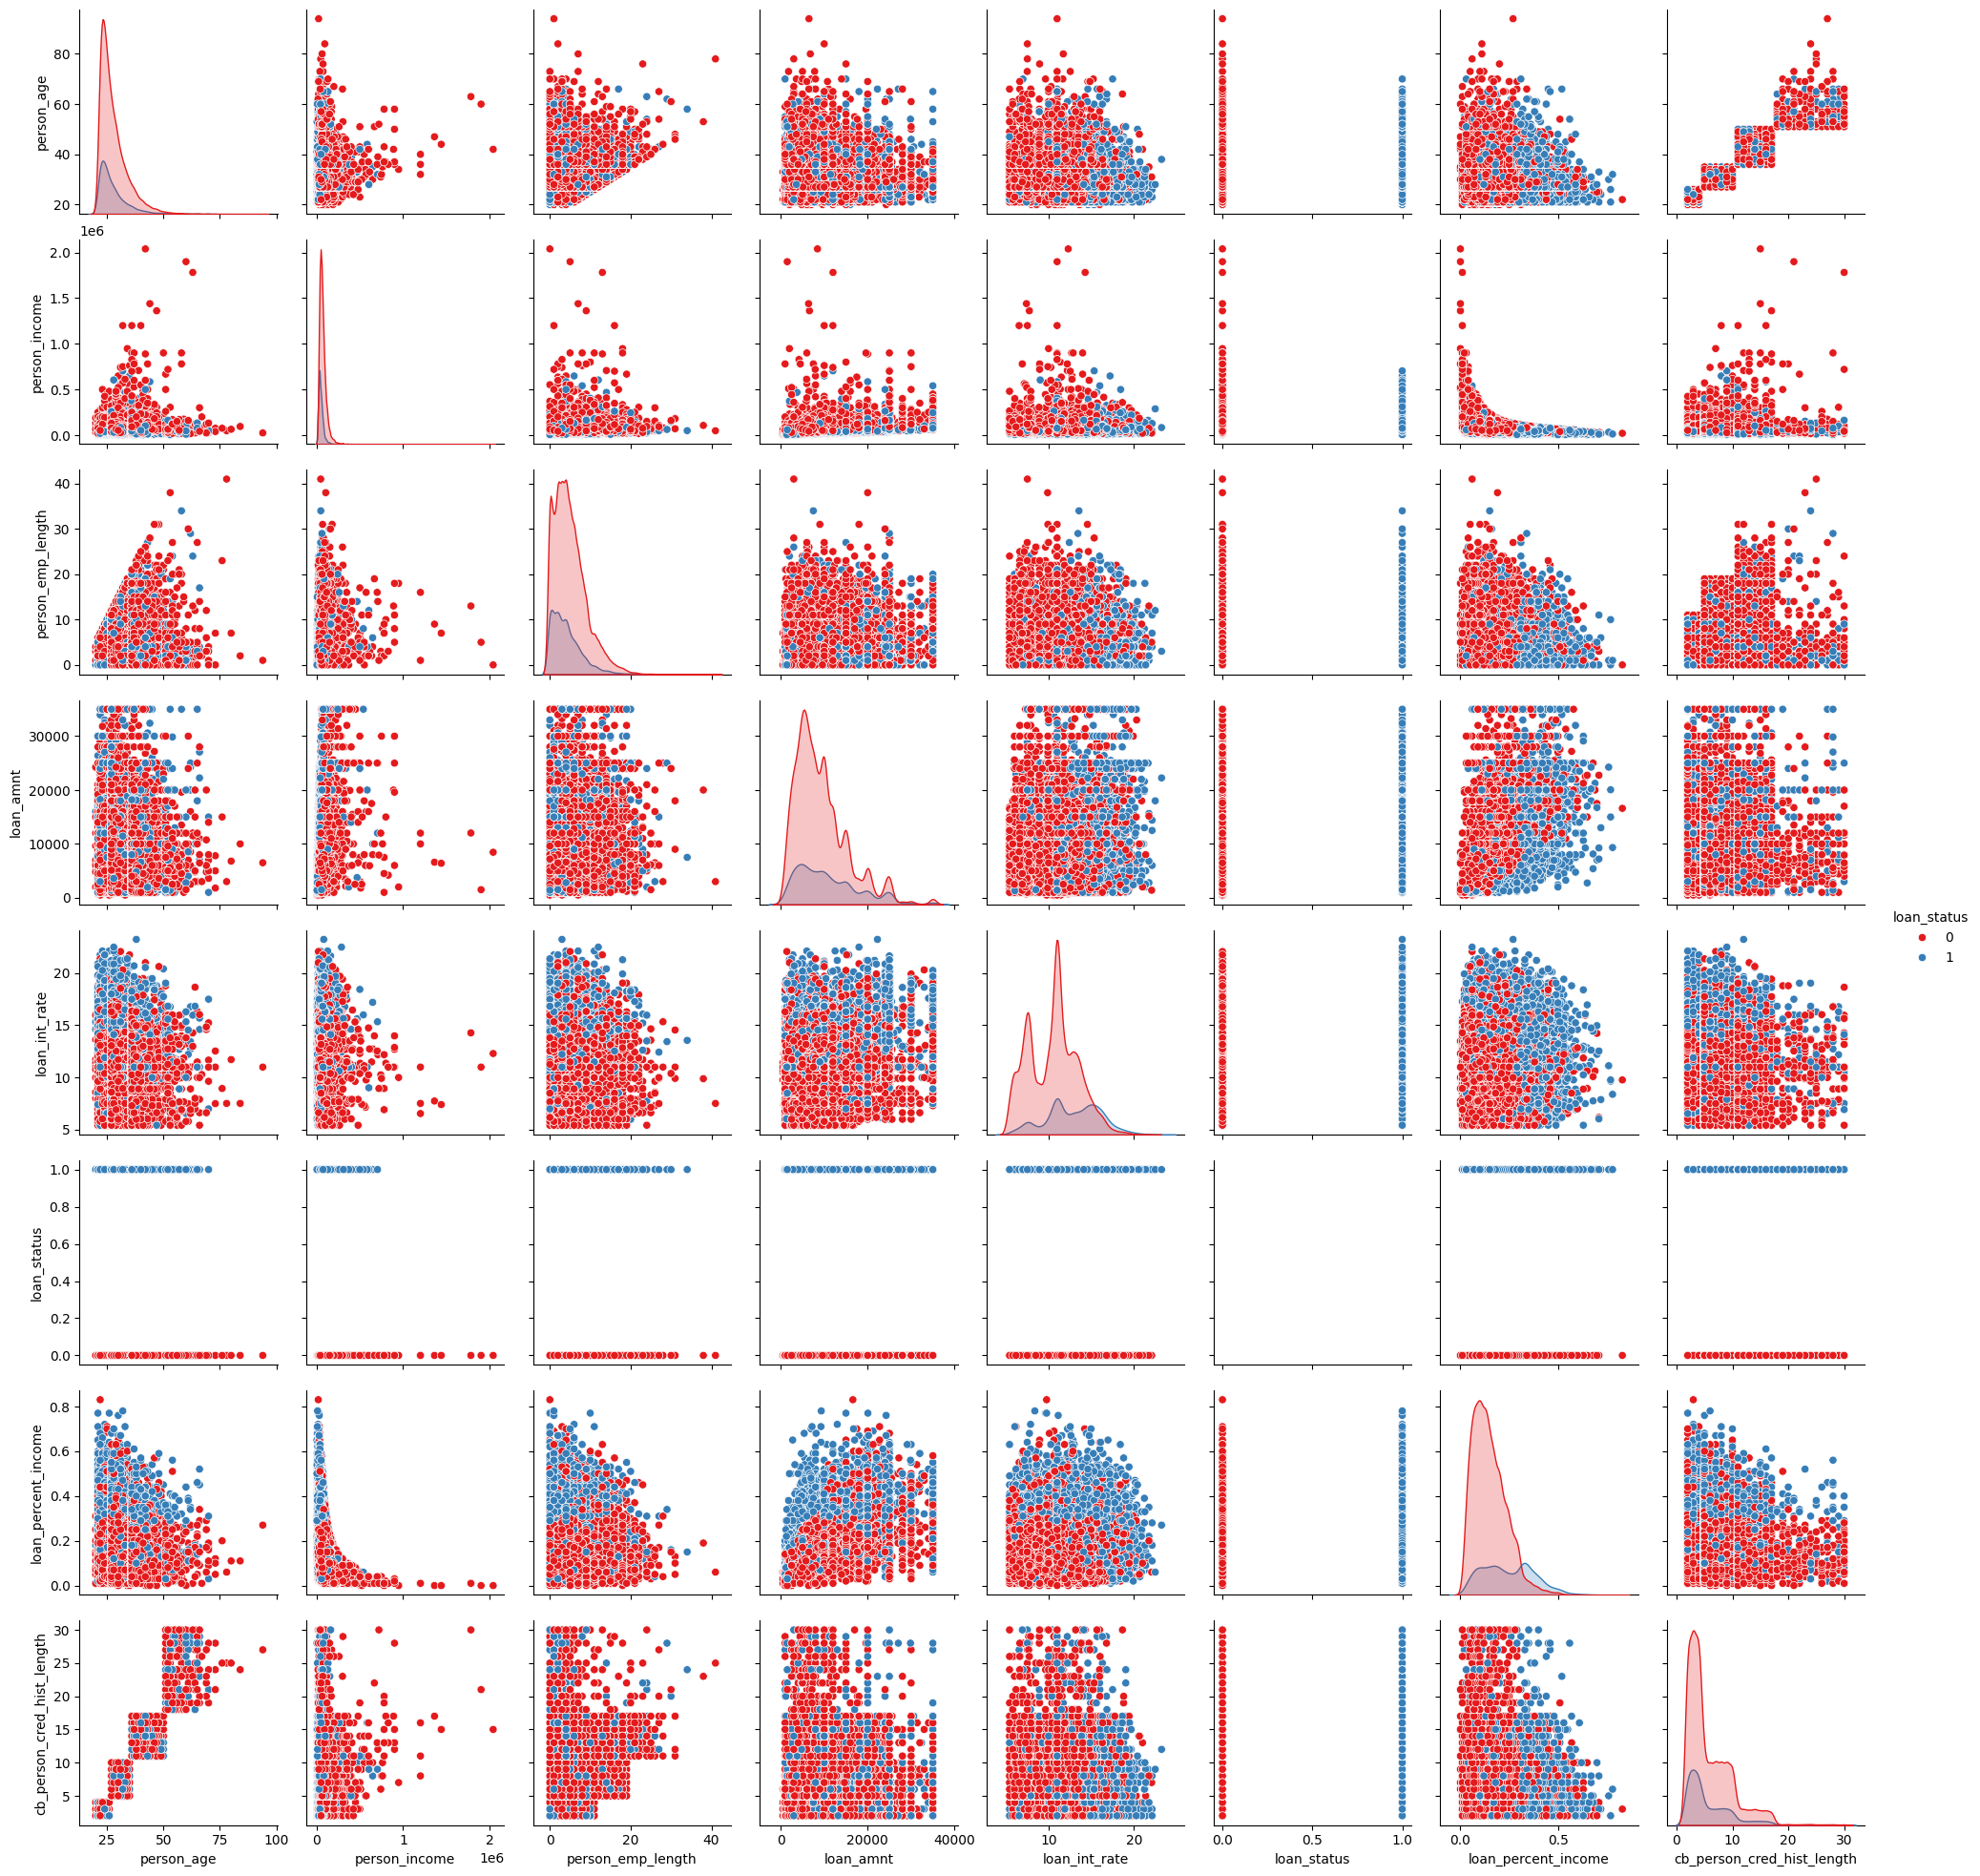

In [10]:
plt.figure(figsize = (18, 18))
sns.pairplot(df, hue = 'loan_status', vars = num_cols, palette = 'Set1')
plt.show();

In [11]:
cat_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32574 non-null  int64  
 1   person_income               32574 non-null  int64  
 2   person_home_ownership       32574 non-null  object 
 3   person_emp_length           32574 non-null  int64  
 4   loan_intent                 32574 non-null  object 
 5   loan_grade                  32574 non-null  object 
 6   loan_amnt                   32574 non-null  int64  
 7   loan_int_rate               32574 non-null  float64
 8   loan_status                 32574 non-null  int64  
 9   loan_percent_income         32574 non-null  float64
 10  cb_person_default_on_file   32574 non-null  object 
 11  cb_person_cred_hist_length  32574 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.0+ MB


Text(0, 0.5, 'Number of Defaults')

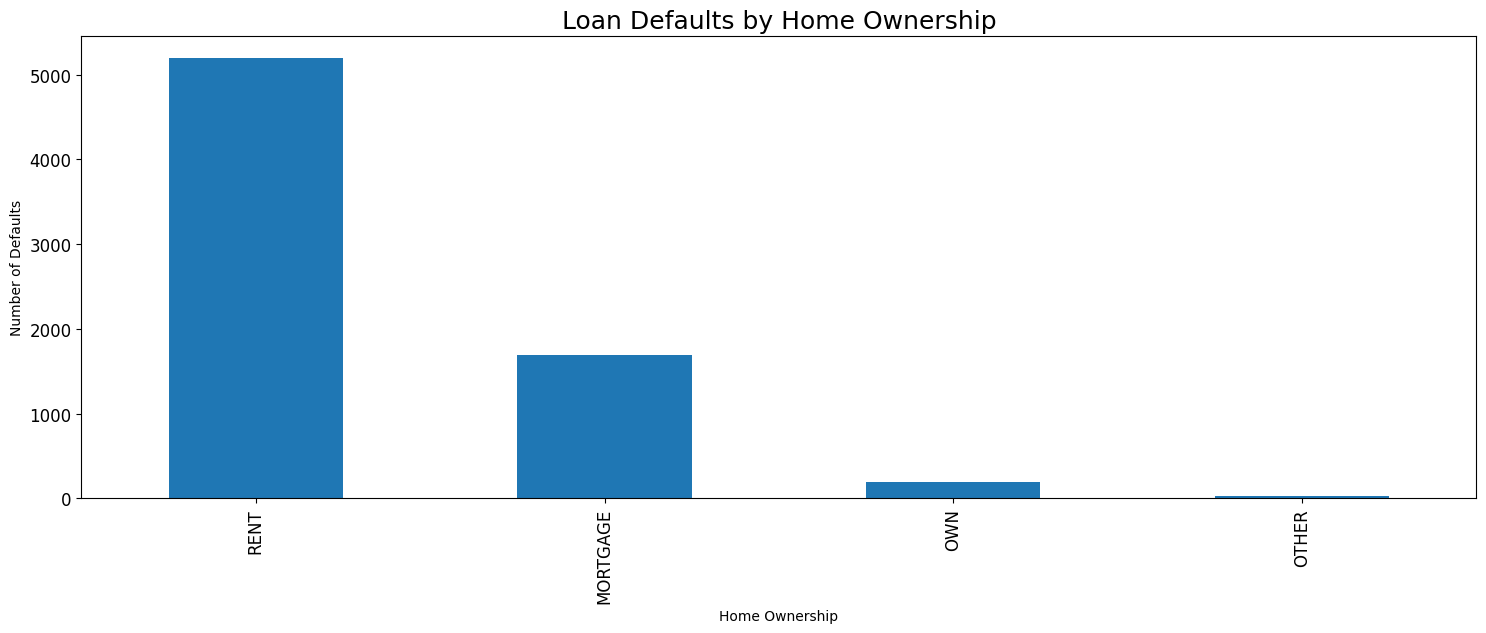

In [24]:
df[df["loan_status"] == 1]["person_home_ownership"].value_counts().plot.bar(figsize=(18, 6), fontsize=12)
plt.title("Loan Defaults by Home Ownership", fontsize=18)
plt.xlabel("Home Ownership")
plt.ylabel("Number of Defaults")


Text(0.5, 1.0, 'Loan Defaults by Default History')

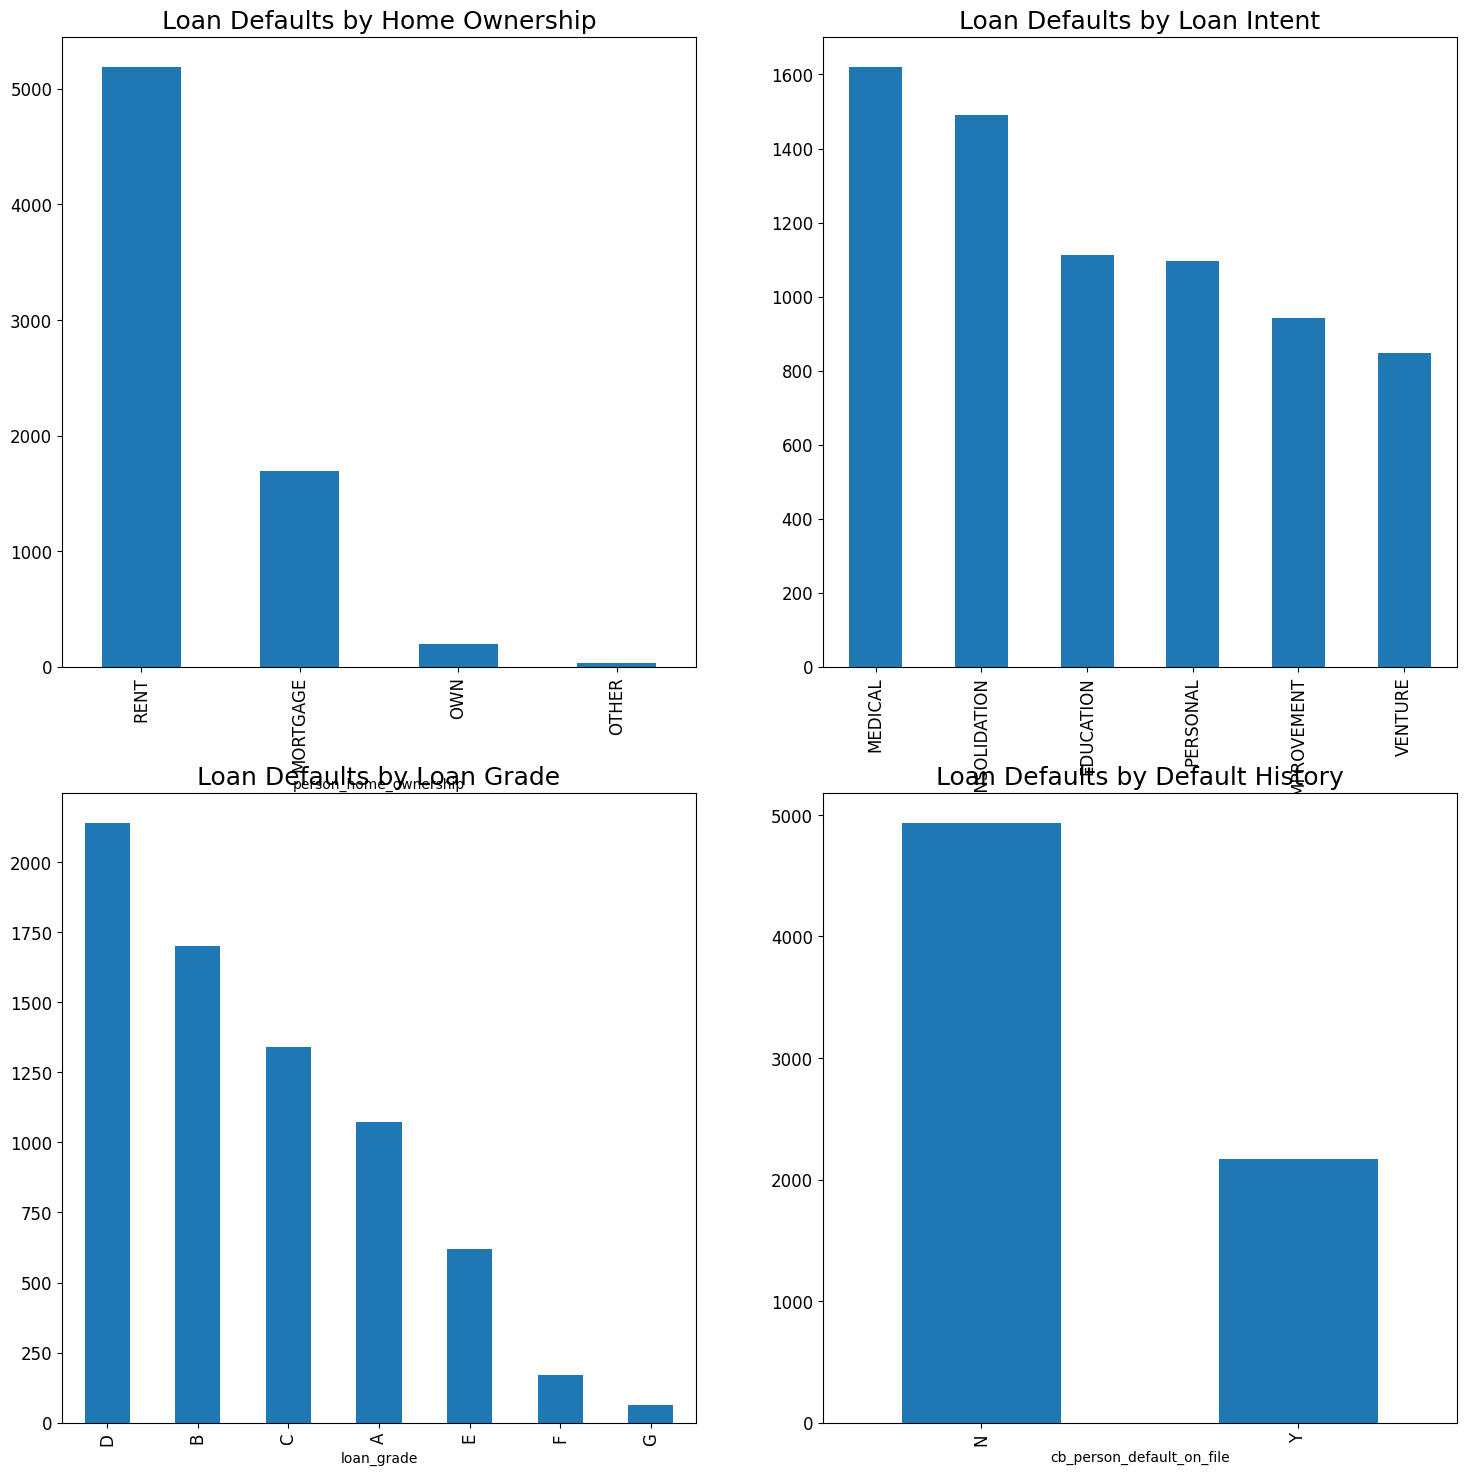

In [25]:
fig, axarr = plt.subplots(2, 2, figsize=(18, 18))

df[df["loan_status"] == 1]["person_home_ownership"].value_counts().plot.bar(ax=axarr[0][0], fontsize=12)
axarr[0][0].set_title("Loan Defaults by Home Ownership", fontsize=18)

df[df["loan_status"] == 1]["loan_intent"].value_counts().plot.bar(ax=axarr[0][1], fontsize=12)
axarr[0][1].set_title("Loan Defaults by Loan Intent", fontsize=18)

df[df["loan_status"] == 1]["loan_grade"].value_counts().plot.bar(ax=axarr[1][0], fontsize=12)
axarr[1][0].set_title("Loan Defaults by Loan Grade", fontsize=18)

df[df["loan_status"] == 1]["cb_person_default_on_file"].value_counts().plot.bar(ax=axarr[1][1], fontsize=12)
axarr[1][1].set_title("Loan Defaults by Default History", fontsize=18)

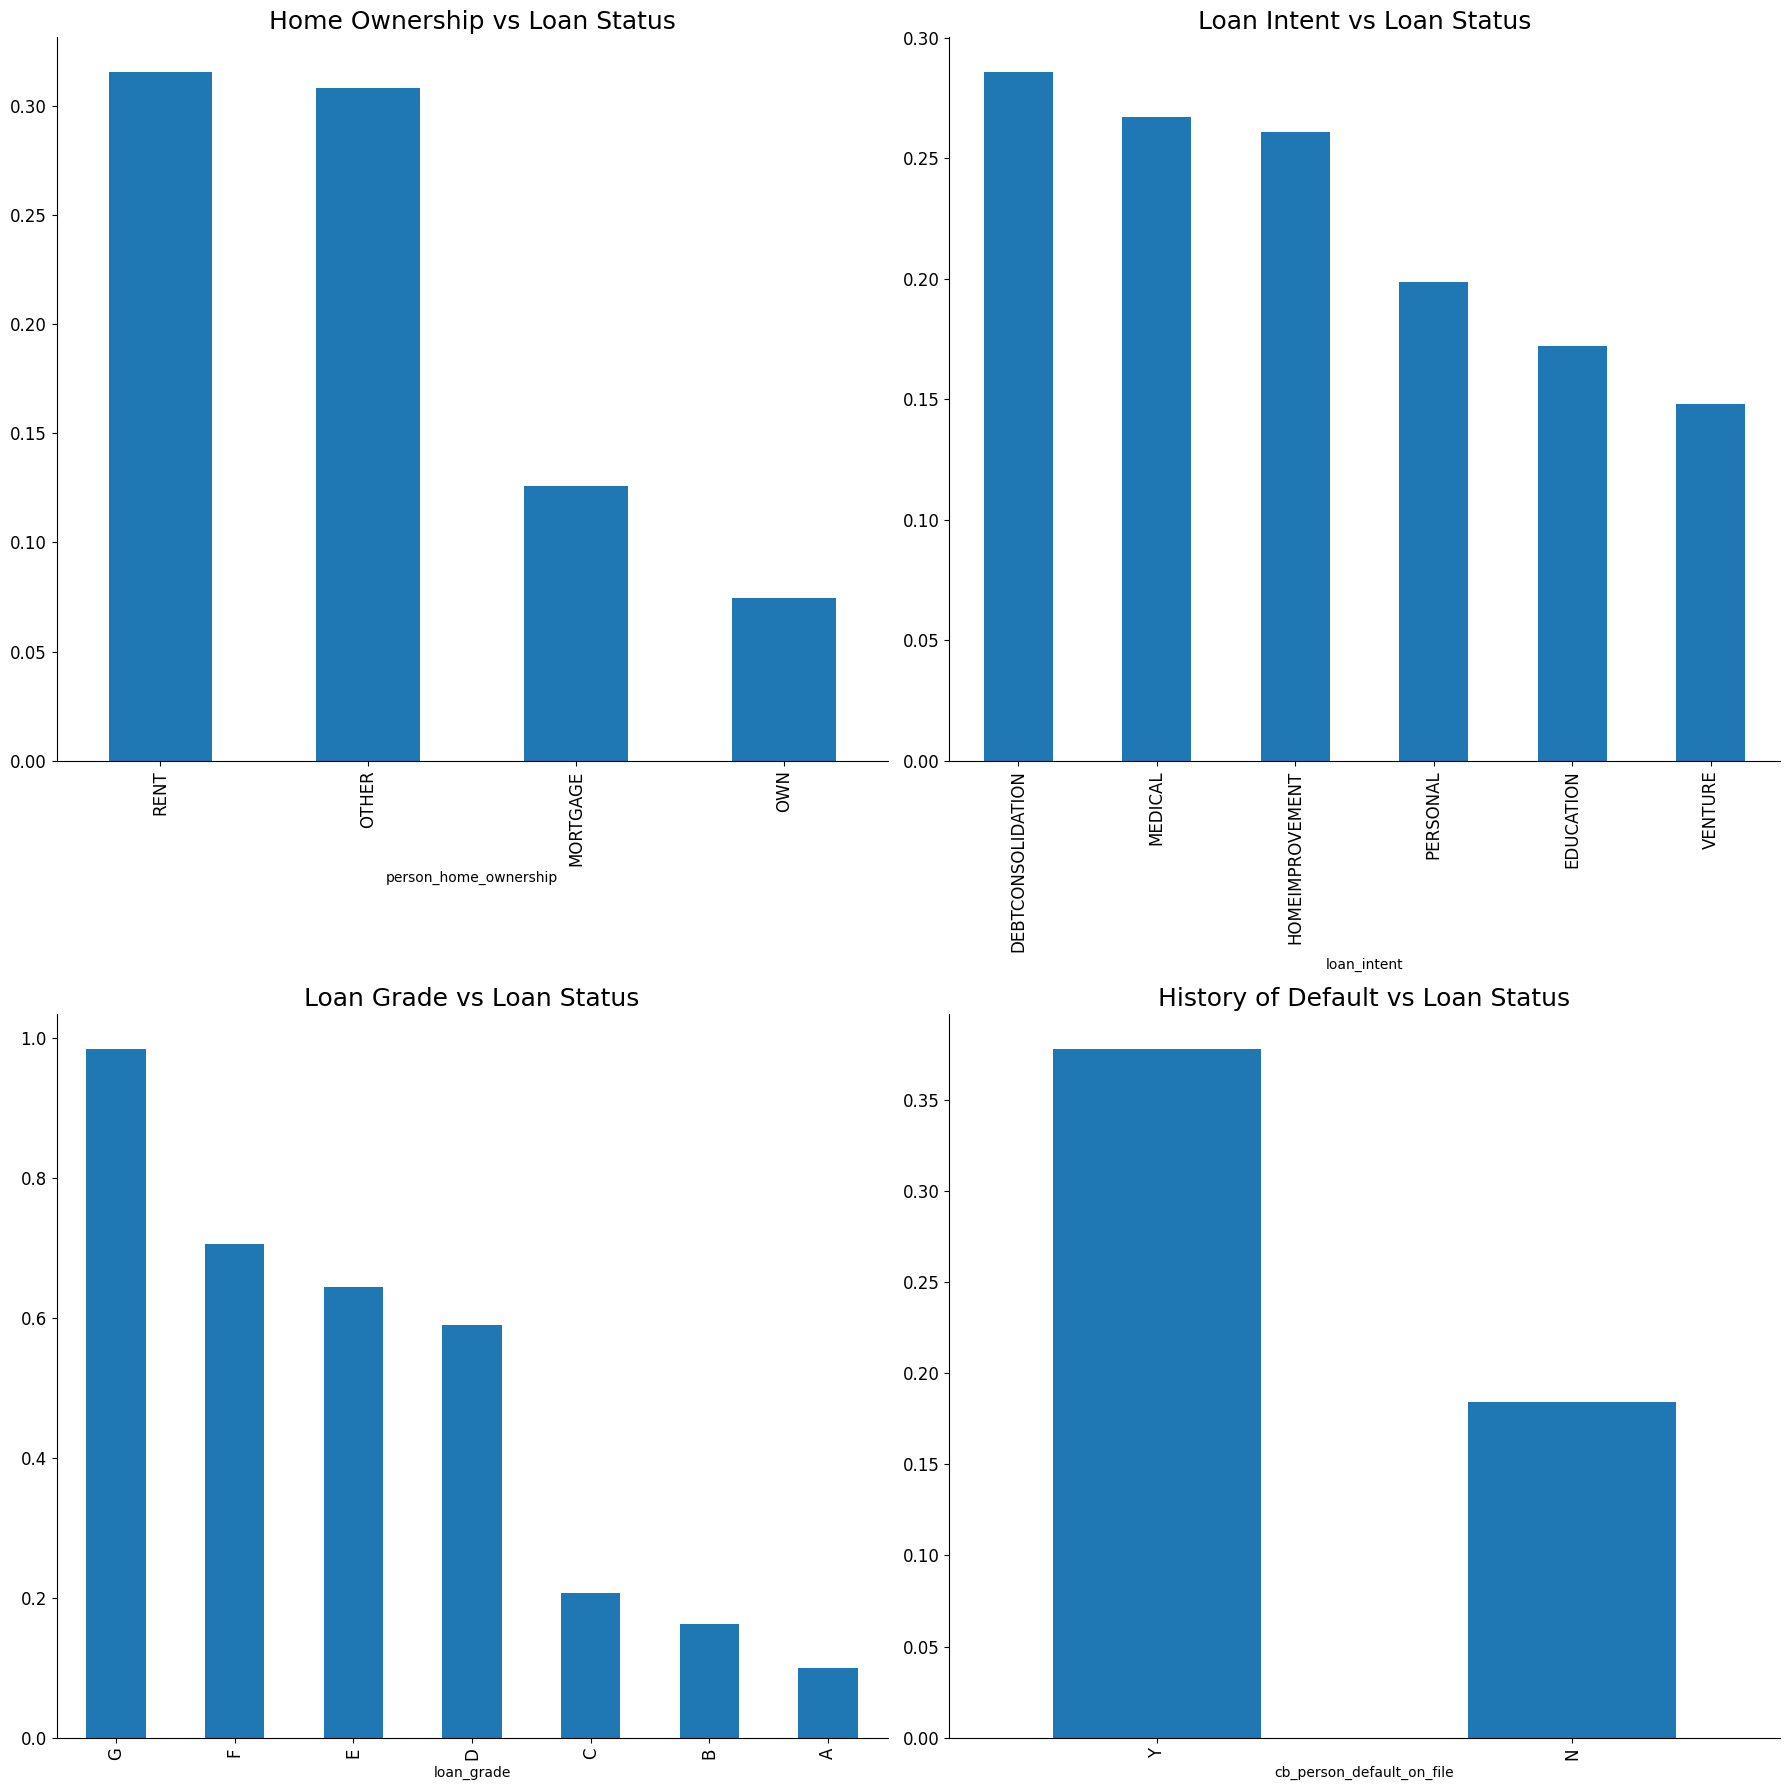

In [26]:
fig, axarr = plt.subplots(2, 2, figsize=(18, 18))
df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False).plot.bar(ax=axarr[0][0], fontsize=12)
axarr[0][0].set_title("Home Ownership vs Loan Status", fontsize=18)

df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False).plot.bar(ax=axarr[0][1], fontsize=12)
axarr[0][1].set_title("Loan Intent vs Loan Status", fontsize=18)

df.groupby('loan_grade')['loan_status'].mean().sort_values(ascending=False).plot.bar(ax=axarr[1][0], fontsize=12)
axarr[1][0].set_title("Loan Grade vs Loan Status", fontsize=18)

df.groupby('cb_person_default_on_file')['loan_status'].mean().sort_values(ascending=False).plot.bar(ax=axarr[1][1], fontsize=12)
axarr[1][1].set_title("History of Default vs Loan Status", fontsize=18)

plt.subplots_adjust(hspace=1.0)
plt.subplots_adjust(wspace=.5)
plt.tight_layout()
sns.despine()

In [14]:
df["loan_status"].value_counts()

loan_status
0    25467
1     7107
Name: count, dtype: int64

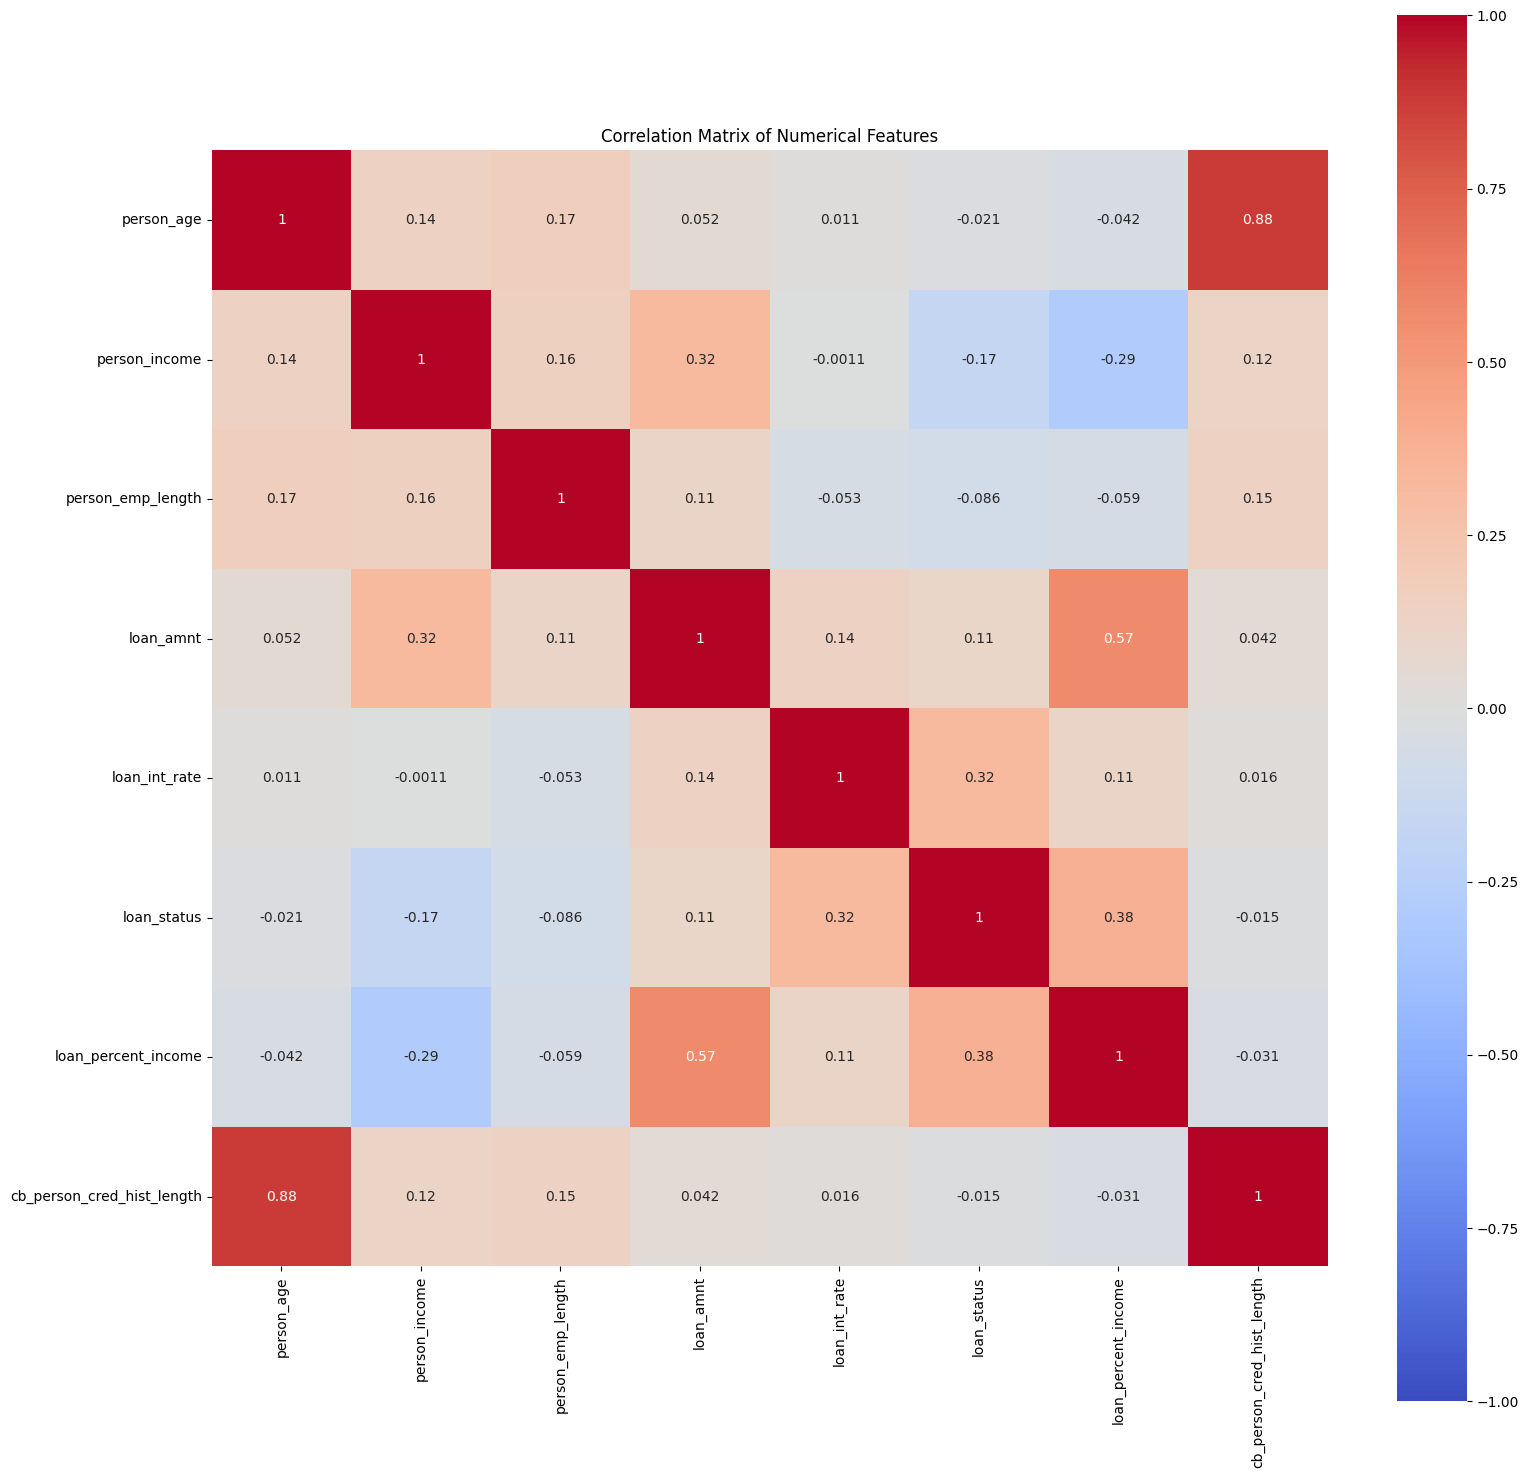

In [15]:
plt.figure(figsize=(18, 18))
sns.heatmap(df[num_cols].corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [16]:
plt.figure(figsize=(10,10))
sns.heatmap(auto.corr(),cbar=True,annot=True,cmap='Blues')

NameError: name 'auto' is not defined

<Figure size 1000x1000 with 0 Axes>